In [1]:
import pandas as pd

listings = pd.read_csv('../data/raw/listings.csv.gz', compression='gzip')
calendar = pd.read_csv('../data/raw/calendar.csv.gz', compression='gzip')
reviews = pd.read_csv('../data/raw/reviews.csv.gz', compression='gzip')
neighbourhoods = pd.read_csv('../data/raw/neighbourhoods.csv')

print("Listings:", listings.shape)
print("Calendar:", calendar.shape)
print("Reviews:", reviews.shape)
print("Neighbourhoods:", neighbourhoods.shape)

Listings: (30259, 90)
Calendar: (11152576, 5)
Reviews: (990170, 6)
Neighbourhoods: (230, 2)


In [2]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 30259 entries, 0 to 30258
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            30259 non-null  int64  
 1   listing_url                                   30259 non-null  str    
 2   scrape_id                                     30259 non-null  int64  
 3   last_scraped                                  30259 non-null  str    
 4   source                                        30259 non-null  str    
 5   name                                          30258 non-null  str    
 6   description                                   29357 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   30259 non-null  str    
 9   host_id                                       30259 non-null  int64  
 1

In [3]:
missing = listings.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(listings) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_summary[missing_summary['missing_count'] > 0])

                             missing_count  missing_pct
neighborhood_overview                30259       100.00
host_since                           30259       100.00
host_response_time                   30259       100.00
host_thumbnail_url                   30259       100.00
host_acceptance_rate                 30259       100.00
host_response_rate                   30259       100.00
host_verifications                   30259       100.00
neighbourhood                        30259       100.00
host_total_listings_count            30259       100.00
host_neighbourhood                   30259       100.00
calendar_updated                     30259       100.00
instant_bookable                     30259       100.00
license                              24973        82.53
host_about                           12410        41.01
bedrooms                             10973        36.26
bathrooms                            10112        33.42
beds                                  9420      

In [4]:
#cleaning code
cols_to_drop = [
    'neighborhood_overview', 'host_since', 'host_response_time',
    'host_response_rate', 'host_acceptance_rate', 'host_thumbnail_url',
    'host_verifications', 'neighbourhood', 'host_total_listings_count',
    'host_neighbourhood', 'calendar_updated', 'instant_bookable',
    'license', 'price_quote_checkin_date', 'price_quote_checkout_date',
    'price_quote_raw', 'host_about'
]
listings_clean = listings.drop(columns=cols_to_drop)

listings_clean = listings_clean.dropna(subset=['price'])

listings_clean['price'] = (
    listings_clean['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

for col in ['bedrooms', 'bathrooms', 'beds']:
    listings_clean[col] = listings_clean[col].fillna(listings_clean[col].median())

review_cols = ['review_scores_rating', 'review_scores_accuracy',
               'review_scores_cleanliness', 'review_scores_checkin',
               'review_scores_communication', 'review_scores_location',
               'review_scores_value', 'reviews_per_month']
listings_clean[review_cols] = listings_clean[review_cols].fillna(0)

listings_clean = listings_clean.dropna(subset=[
    'host_name', 'host_is_superhost', 'bathrooms_text',
    'minimum_nights', 'name', 'has_availability'
])

print(listings_clean.shape)
print(listings_clean.isnull().sum().sum())

(21083, 73)
17708


In [5]:
remaining = listings_clean.isnull().sum()
remaining = remaining[remaining > 0].sort_values(ascending=False)
print(remaining)

last_review                    5890
first_review                   5890
host_location                  5667
description                     258
host_profile_url                  1
price_quote_price_per_night       1
price_quote_total_price           1
dtype: int64


In [6]:
listings_clean = listings_clean.drop(columns=[
    'last_review', 'first_review', 'host_location',
    'description', 'host_profile_url'
])

listings_clean = listings_clean.dropna(subset=[
    'price_quote_price_per_night', 'price_quote_total_price'
])

print(listings_clean.shape)
print(listings_clean.isnull().sum().sum())

(21082, 68)
0


In [7]:
listings_clean.to_csv('../data/processed/listings_clean.csv', index=False)

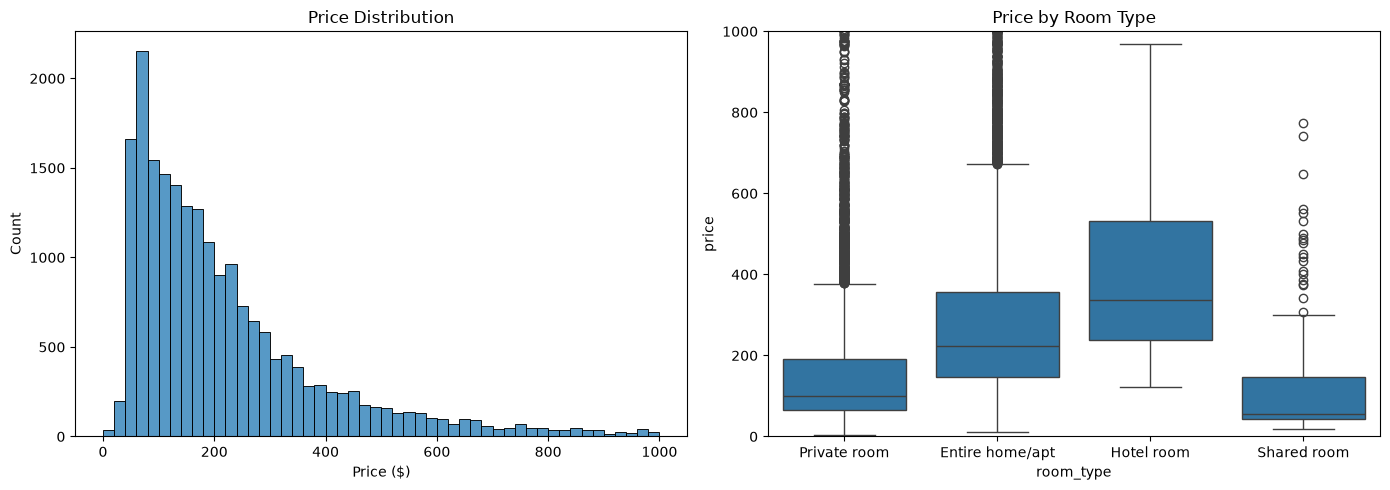

In [9]:
#EDA
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(listings_clean['price'], bins=50, binrange=(0, 1000), ax=axes[0])
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price ($)')

sns.boxplot(data=listings_clean, x='room_type', y='price', ax=axes[1])
axes[1].set_title('Price by Room Type')
axes[1].set_ylim(0, 1000)

plt.tight_layout()
plt.show()

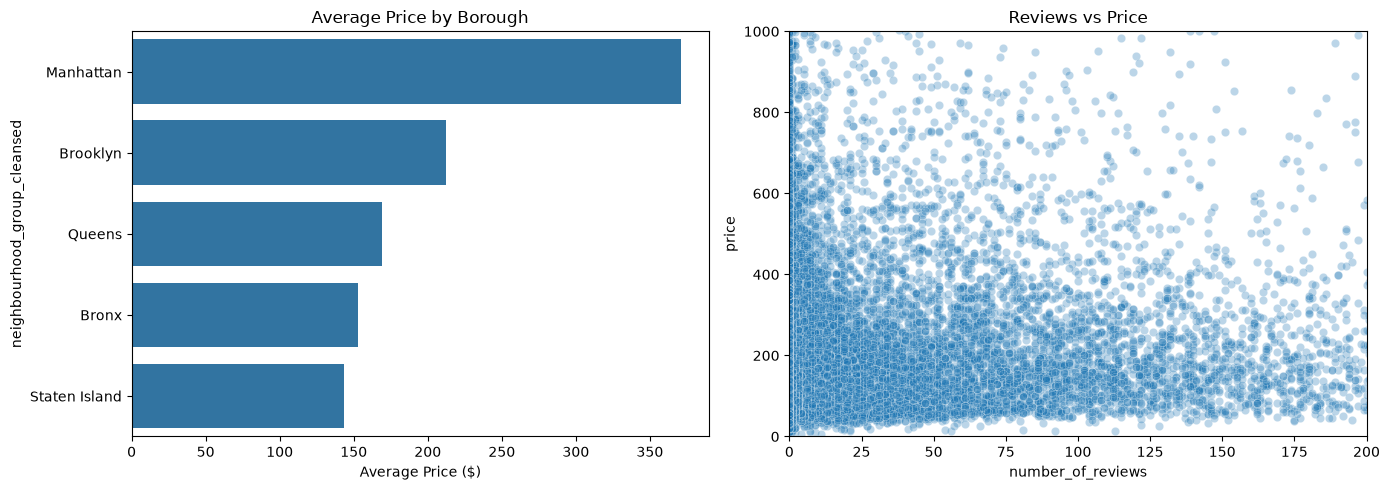

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_neighbourhoods = listings_clean.groupby('neighbourhood_group_cleansed')['price'].mean().sort_values(ascending=False)
sns.barplot(x=top_neighbourhoods.values, y=top_neighbourhoods.index, ax=axes[0])
axes[0].set_title('Average Price by Borough')
axes[0].set_xlabel('Average Price ($)')

sns.scatterplot(data=listings_clean, x='number_of_reviews', y='price', alpha=0.3, ax=axes[1])
axes[1].set_title('Reviews vs Price')
axes[1].set_ylim(0, 1000)
axes[1].set_xlim(0, 200)

plt.tight_layout()
plt.show()

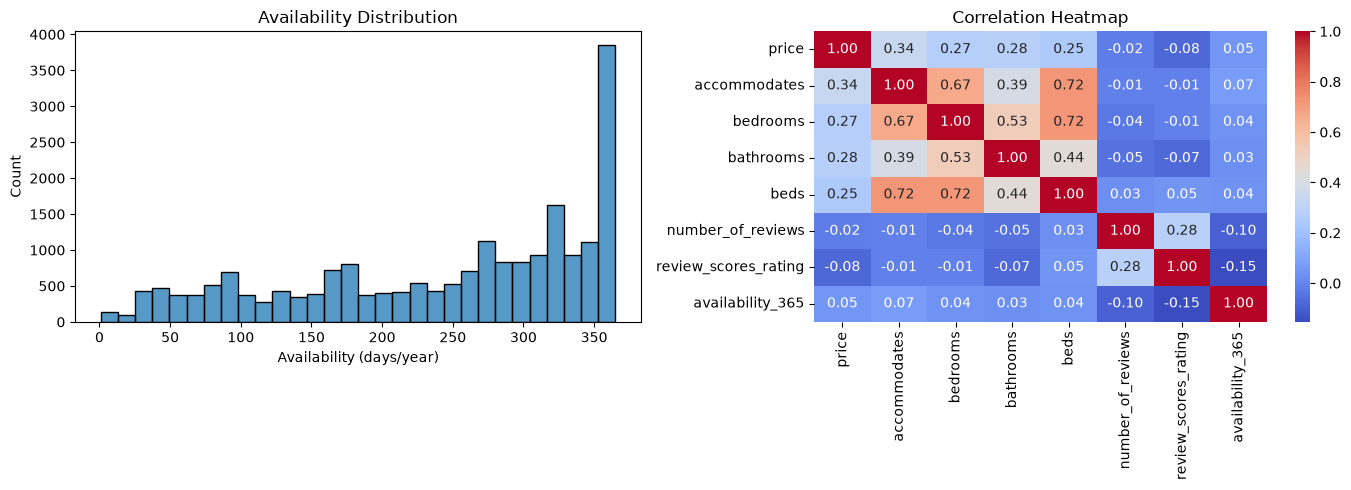

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(listings_clean['availability_365'], bins=30, ax=axes[0])
axes[0].set_title('Availability Distribution')
axes[0].set_xlabel('Availability (days/year)')

numeric_cols = ['price', 'accommodates', 'bedrooms', 'bathrooms', 'beds',
                 'number_of_reviews', 'review_scores_rating', 'availability_365']
corr = listings_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

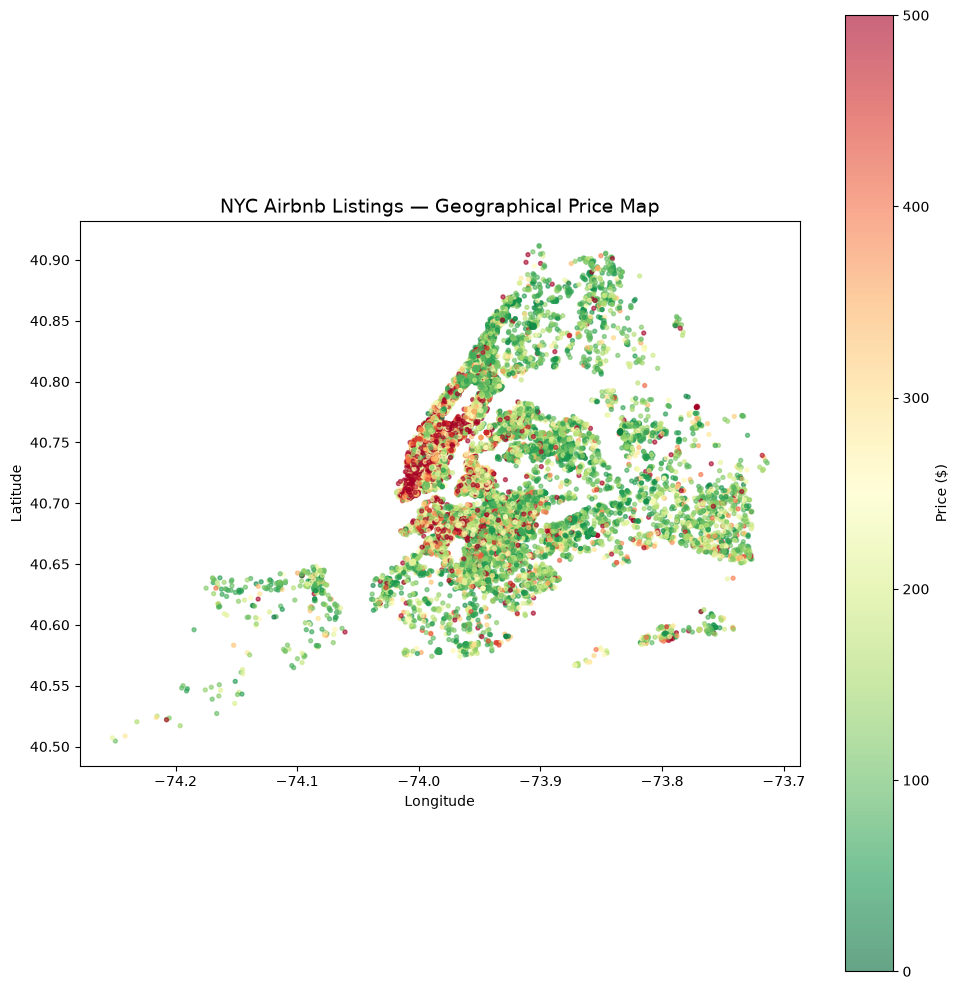

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))

scatter = ax.scatter(
    listings_clean['longitude'],
    listings_clean['latitude'],
    c=listings_clean['price'],
    cmap='RdYlGn_r',
    s=8,
    alpha=0.6,
    vmin=0,
    vmax=500
)

plt.colorbar(scatter, label='Price ($)', ax=ax)
ax.set_title('NYC Airbnb Listings — Geographical Price Map', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd

listings_clean = pd.read_csv('../data/processed/listings_clean.csv')
print(listings_clean.shape)

(21082, 68)


In [3]:
listings_clean['neighbourhood_group'] = listings_clean['neighbourhood_group_cleansed']

listings_clean['review_velocity'] = listings_clean['reviews_per_month']

listings_clean['availability_rate'] = listings_clean['availability_365'] / 365

listings_clean['minimum_nights_category'] = pd.cut(
    listings_clean['minimum_nights'],
    bins=[0, 3, 7, 30, float('inf')],
    labels=['short', 'weekly', 'monthly', 'long_term']
)

listings_clean['host_activity_score'] = (
    listings_clean['host_listings_count'] * 0.5 +
    listings_clean['number_of_reviews'] * 0.5
)

listings_clean['price_category'] = pd.cut(
    listings_clean['price'],
    bins=[0, 100, 250, 500, float('inf')],
    labels=['budget', 'mid', 'premium', 'luxury']
)

print(listings_clean[['neighbourhood_group', 'review_velocity', 'availability_rate',
                       'minimum_nights_category', 'host_activity_score', 'price_category']].head())

print(listings_clean['minimum_nights_category'].value_counts())
print(listings_clean['minimum_nights'].describe())

  neighbourhood_group  review_velocity  availability_rate  \
0            Brooklyn             0.08           0.928767   
1            Brooklyn             0.95           0.523288   
2           Manhattan             0.04           0.783562   
3           Manhattan             1.24           0.597260   
4            Brooklyn             2.12           0.290411   

  minimum_nights_category  host_activity_score price_category  
0                 monthly                  7.5            mid  
1                 monthly                 99.5            mid  
2                 monthly                  2.0         budget  
3                 monthly                126.0         budget  
4                 monthly                212.5            mid  
minimum_nights_category
monthly      15937
short         4292
long_term      577
weekly         276
Name: count, dtype: int64
count    21082.000000
mean        24.956408
std         18.064827
min          1.000000
25%         30.000000
50%         3

In [5]:
import numpy as np

manhattan_lat, manhattan_lon = 40.7831, -73.9712

listings_clean['distance_to_manhattan'] = np.sqrt(
    (listings_clean['latitude'] - manhattan_lat) ** 2 +
    (listings_clean['longitude'] - manhattan_lon) ** 2
)

print(listings_clean[['latitude', 'longitude', 'distance_to_manhattan']].head())
print(listings_clean['distance_to_manhattan'].describe())

listings_clean.to_csv('../data/processed/listings_features.csv', index=False)
print("Saved:", listings_clean.shape)

    latitude  longitude  distance_to_manhattan
0  40.645937 -73.972164               0.137166
1  40.709350 -73.953420               0.075863
2  40.801070 -73.942550               0.033819
3  40.787780 -73.947590               0.024069
4  40.691940 -73.973890               0.091200
count    21082.000000
mean         0.087986
std          0.058822
min          0.000624
25%          0.039364
50%          0.075851
75%          0.118992
max          0.393703
Name: distance_to_manhattan, dtype: float64
Saved: (21082, 75)


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

feature_cols = [
    'neighbourhood_group_cleansed', 'room_type', 'accommodates',
    'bedrooms', 'bathrooms', 'beds', 'minimum_nights',
    'number_of_reviews', 'review_scores_rating', 'availability_365',
    'host_listings_count', 'host_is_superhost',
    'review_velocity', 'availability_rate', 'host_activity_score',
    'distance_to_manhattan'
]

X = listings_clean[feature_cols].copy()
y = listings_clean['price']

categorical_cols = ['neighbourhood_group_cleansed', 'room_type', 'host_is_superhost']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (16865, 16)
Test shape: (4217, 16)


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print(results_df)

               Model         MAE        RMSE        R2
2      Random Forest  108.942501  343.677730  0.378906
0  Linear Regression  151.042427  379.191120  0.243915
3  Gradient Boosting  120.689492  416.081213  0.089646
4            XGBoost  115.442692  444.486013 -0.038892
1      Decision Tree  145.059965  564.681016 -0.676720


In [8]:
print(y_train.describe())
print("Prices > 1000:", (y_train > 1000).sum())
print("Prices > 2000:", (y_train > 2000).sum())

count    16865.000000
mean       271.562805
std        523.851265
min          7.200000
25%         94.980000
50%        171.010000
75%        296.000000
max      30972.960000
Name: price, dtype: float64
Prices > 1000: 465
Prices > 2000: 119


In [9]:
price_cap = listings_clean['price'].quantile(0.99)
print("99th percentile price cap:", price_cap)

listings_model = listings_clean[listings_clean['price'] <= price_cap].copy()
print("Rows before:", listings_clean.shape[0], "| after capping:", listings_model.shape[0])

X = listings_model[feature_cols].copy()
y = listings_model['price']

for col in categorical_cols:
    X[col] = label_encoders[col].transform(X[col])

y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


99th percentile price cap: 1661.5360999999998
Rows before: 21082 | after capping: 20871
Train shape: (16696, 16)
Test shape: (4175, 16)


In [10]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)

    y_pred = np.expm1(y_pred_log)
    y_test_actual = np.expm1(y_test)

    mae = mean_absolute_error(y_test_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
    r2 = r2_score(y_test_actual, y_pred)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print(results_df)


               Model        MAE        RMSE        R2
4            XGBoost  69.212482  133.573191  0.632653
2      Random Forest  68.959551  133.719570  0.631847
3  Gradient Boosting  77.248692  146.371728  0.558885
0  Linear Regression  95.289062  170.536129  0.401215
1      Decision Tree  95.116090  181.382952  0.322622


In [11]:
best_model = models['XGBoost']

importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importances)


                         feature  importance
6                 minimum_nights    0.231278
2                   accommodates    0.230152
1                      room_type    0.217633
4                      bathrooms    0.079475
3                       bedrooms    0.050245
10           host_listings_count    0.043608
15         distance_to_manhattan    0.031846
0   neighbourhood_group_cleansed    0.025370
9               availability_365    0.016700
12               review_velocity    0.016128
14           host_activity_score    0.013906
11             host_is_superhost    0.013244
5                           beds    0.012757
8           review_scores_rating    0.010685
7              number_of_reviews    0.006975
13             availability_rate    0.000000


In [12]:
feature_cols = [
    'neighbourhood_group_cleansed', 'room_type', 'accommodates',
    'bedrooms', 'bathrooms', 'beds', 'minimum_nights',
    'number_of_reviews', 'review_scores_rating', 'availability_365',
    'host_listings_count', 'host_is_superhost',
    'review_velocity', 'host_activity_score',
    'distance_to_manhattan'
]

X = listings_model[feature_cols].copy()
y = listings_model['price']

for col in categorical_cols:
    X[col] = label_encoders[col].transform(X[col])

y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)

    y_pred = np.expm1(y_pred_log)
    y_test_actual = np.expm1(y_test)

    mae = mean_absolute_error(y_test_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
    r2 = r2_score(y_test_actual, y_pred)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print(results_df)

               Model        MAE        RMSE        R2
4            XGBoost  69.212482  133.573191  0.632653
2      Random Forest  68.913751  133.681742  0.632056
3  Gradient Boosting  77.248692  146.371728  0.558885
0  Linear Regression  95.289062  170.536129  0.401215
1      Decision Tree  94.716105  179.206510  0.338781


In [13]:
import joblib

best_model = models['XGBoost']
joblib.dump(best_model, '../models/price_model_xgboost.pkl')
joblib.dump(label_encoders, '../models/label_encoders.pkl')

print("Model and encoders saved.")

Model and encoders saved.


In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best params:", xgb_grid.best_params_)
print("Best CV R2:", xgb_grid.best_score_)

Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
Best CV R2: 0.7790622576648486


In [15]:
best_xgb = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

best_xgb.fit(X_train, y_train)
y_pred_log = best_xgb.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2 = r2_score(y_test_actual, y_pred)

print(f"Tuned XGBoost — MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.4f}")

Tuned XGBoost — MAE: 68.52, RMSE: 133.05, R2: 0.6355


In [16]:
joblib.dump(best_xgb, '../models/price_model_xgboost.pkl')
print("Updated model saved (tuned, marginal improvement).")

Updated model saved (tuned, marginal improvement).


In [17]:
print(listings_model['estimated_occupancy_l365d'].describe())

count    20871.000000
mean        70.386661
std         95.270804
min          0.000000
25%          0.000000
50%          0.000000
75%        120.000000
max        255.000000
Name: estimated_occupancy_l365d, dtype: float64


In [19]:
zero_count = (listings_model['estimated_occupancy_l365d'] == 0).sum()
print(f"Zero occupancy: {zero_count} ({zero_count/len(listings_model)*100:.1f}%)")
print(listings_model['estimated_occupancy_l365d'].value_counts().head(10))

Zero occupancy: 11397 (54.6%)
estimated_occupancy_l365d
0      11397
255     2676
60      2287
120     1383
180      951
240      500
13       161
26       113
38       104
90        91
Name: count, dtype: int64


In [20]:
listings_model['demand_label'] = (listings_model['estimated_occupancy_l365d'] > 0).astype(int)

print(listings_model['demand_label'].value_counts())
print(listings_model['demand_label'].value_counts(normalize=True))

demand_label
0    11397
1     9474
Name: count, dtype: int64
demand_label
0    0.546069
1    0.453931
Name: proportion, dtype: float64


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

clf_feature_cols = [
    'neighbourhood_group_cleansed', 'room_type', 'accommodates',
    'bedrooms', 'bathrooms', 'beds', 'minimum_nights',
    'price', 'availability_365', 'host_listings_count',
    'host_is_superhost', 'distance_to_manhattan'
]

X_clf = listings_model[clf_feature_cols].copy()
y_clf = listings_model['demand_label']

for col in categorical_cols:
    X_clf[col] = label_encoders[col].transform(X_clf[col])

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Train shape:", X_train_clf.shape)
print("Test shape:", X_test_clf.shape)

Train shape: (16696, 12)
Test shape: (4175, 12)


In [22]:
clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42)
}

clf_results = []

for name, model in clf_models.items():
    model.fit(X_train_clf, y_train_clf)
    y_pred_clf = model.predict(X_test_clf)

    acc = accuracy_score(y_test_clf, y_pred_clf)
    prec = precision_score(y_test_clf, y_pred_clf)
    rec = recall_score(y_test_clf, y_pred_clf)
    f1 = f1_score(y_test_clf, y_pred_clf)

    clf_results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})

clf_results_df = pd.DataFrame(clf_results).sort_values('F1', ascending=False)
print(clf_results_df)

c:\Users\Jyoshini N T\Documents\smart-airbnb\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Accuracy  Precision    Recall        F1
3              XGBoost  0.792335   0.782108  0.751979  0.766747
2        Random Forest  0.790419   0.785554  0.740369  0.762293
0  Logistic Regression  0.762635   0.776622  0.669657  0.719184
1        Decision Tree  0.736766   0.702030  0.729815  0.715653


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clf)
X_test_scaled = scaler.transform(X_test_clf)

log_reg_scaled = LogisticRegression(max_iter=1000, random_state=42)
log_reg_scaled.fit(X_train_scaled, y_train_clf)
y_pred_scaled = log_reg_scaled.predict(X_test_scaled)

acc = accuracy_score(y_test_clf, y_pred_scaled)
prec = precision_score(y_test_clf, y_pred_scaled)
rec = recall_score(y_test_clf, y_pred_scaled)
f1 = f1_score(y_test_clf, y_pred_scaled)

print(f"Scaled Logistic Regression — Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

Scaled Logistic Regression — Accuracy: 0.7634, Precision: 0.7784, Recall: 0.6691, F1: 0.7196


In [24]:
best_clf = clf_models['XGBoost']
joblib.dump(best_clf, '../models/demand_model_xgboost.pkl')
print("Demand classification model saved.")

Demand classification model saved.


In [25]:
demand_importances = pd.DataFrame({
    'feature': clf_feature_cols,
    'importance': best_clf.feature_importances_
}).sort_values('importance', ascending=False)

print(demand_importances)

                         feature  importance
6                 minimum_nights    0.362434
10             host_is_superhost    0.317053
1                      room_type    0.067605
9            host_listings_count    0.060193
8               availability_365    0.038381
7                          price    0.028312
3                       bedrooms    0.025268
0   neighbourhood_group_cleansed    0.023192
11         distance_to_manhattan    0.021546
2                   accommodates    0.021168
5                           beds    0.017920
4                      bathrooms    0.016928


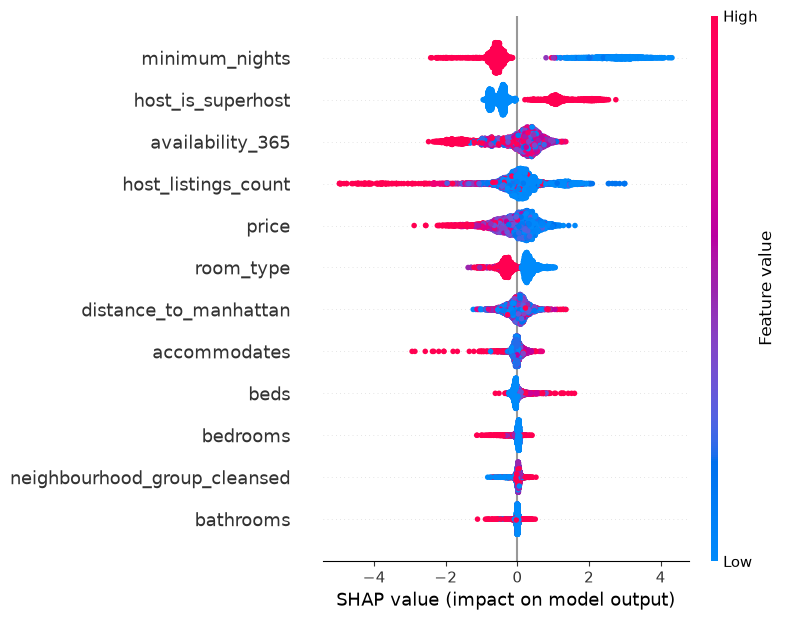

In [26]:
import shap

explainer = shap.TreeExplainer(best_clf)
shap_values = explainer.shap_values(X_test_clf)

shap.summary_plot(shap_values, X_test_clf, feature_names=clf_feature_cols)

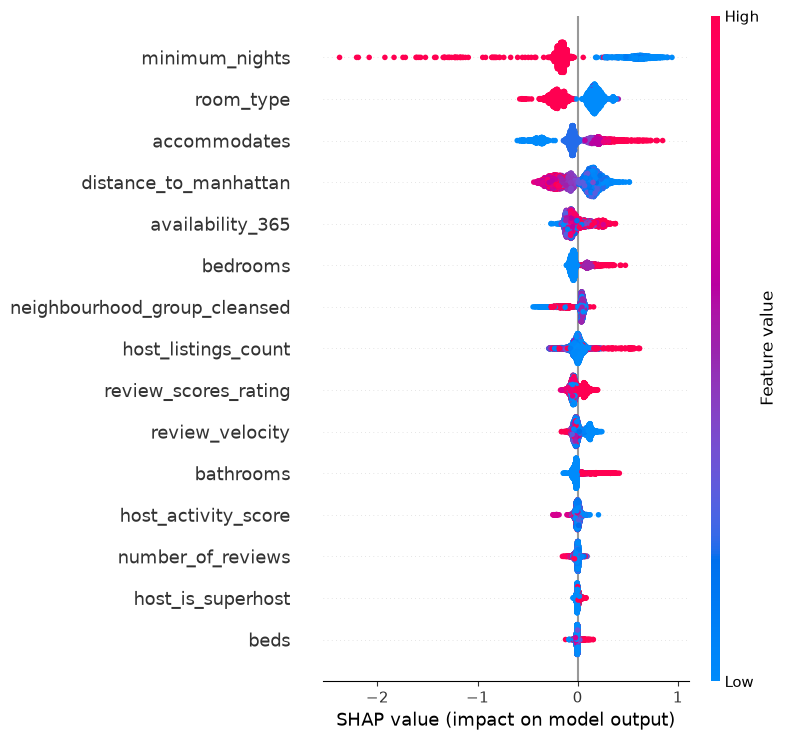

In [27]:
explainer_price = shap.TreeExplainer(best_xgb)
shap_values_price = explainer_price.shap_values(X_test)

shap.summary_plot(shap_values_price, X_test, feature_names=feature_cols)

In [28]:
print(list(label_encoders['room_type'].classes_))


['Entire home/apt', 'Hotel room', 'Private room', 'Shared room']


In [29]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

st.set_page_config(page_title="Smart Airbnb Intelligence", layout="wide")

price_model = joblib.load('../models/price_model_xgboost.pkl')
demand_model = joblib.load('../models/demand_model_xgboost.pkl')
label_encoders = joblib.load('../models/label_encoders.pkl')

st.title("🏠 Smart Airbnb Intelligence")
st.markdown("Predict price and demand for NYC Airbnb listings")

2026-09-25 10:57:31.625 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-25 10:57:31.690 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-25 10:57:32.844 
  command:

    streamlit run c:\Users\Jyoshini N T\Documents\smart-airbnb\venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-25 10:57:32.846 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-25 10:57:32.847 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-25 10:57:32.848 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-25 10:57:32.849 Thread 'MainThread': missing ScriptRunContext! This warning

DeltaGenerator()